In [139]:
import os
import cv2
import numpy as np

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [140]:
image_folder = "C:/Users/ksent/OneDrive/Desktop/Facemask/images"

In [141]:
dataset_path = "C:/Users/ksent/OneDrive/Desktop/Facemask/images"
print("Training images:", os.listdir(dataset_path))
print("Testing images:", os.listdir(dataset_path))

Training images: ['maksssksksss0.png', 'maksssksksss1.png', 'maksssksksss10.png', 'maksssksksss100.png', 'maksssksksss101.png', 'maksssksksss102.png', 'maksssksksss103.png', 'maksssksksss104.png', 'maksssksksss105.png', 'maksssksksss106.png', 'maksssksksss107.png', 'maksssksksss108.png', 'maksssksksss109.png', 'maksssksksss11.png', 'maksssksksss110.png', 'maksssksksss111.png', 'maksssksksss112.png', 'maksssksksss113.png', 'maksssksksss114.png', 'maksssksksss115.png', 'maksssksksss116.png', 'maksssksksss117.png', 'maksssksksss118.png', 'maksssksksss119.png', 'maksssksksss12.png', 'maksssksksss120.png', 'maksssksksss121.png', 'maksssksksss122.png', 'maksssksksss123.png', 'maksssksksss124.png', 'maksssksksss125.png', 'maksssksksss126.png', 'maksssksksss127.png', 'maksssksksss128.png', 'maksssksksss129.png', 'maksssksksss13.png', 'maksssksksss130.png', 'maksssksksss131.png', 'maksssksksss132.png', 'maksssksksss133.png', 'maksssksksss134.png', 'maksssksksss135.png', 'maksssksksss136.png', '

In [142]:
data = []
labels = []

In [143]:
image_dir = "C:/Users/ksent/OneDrive/Desktop/Facemask/images"


total_images = len(os.listdir(image_dir))
print("Total images in dataset:", total_images)

Total images in dataset: 853


In [144]:
for img_name in os.listdir(image_folder):
    
    img_path = os.path.join(image_folder, img_name)
    
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    try:
        img = cv2.resize(img, (100,100))
    except:
        continue
    
    # Dummy labels (for project run)
    label = 0 if len(data) % 2 == 0 else 1
    
    data.append(img)
    labels.append(label)


print("Total Images Loaded:", len(data))

Total Images Loaded: 853


In [145]:
data = np.array(data, dtype="float32") / 255.0
labels = np.array(labels)



In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 682
Testing samples: 171


In [147]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [148]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

In [149]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(2,activation='softmax'))

model.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353,346 (16.61 MB)

 Trainable params: 4,353,346 (16.61 MB)

 Non-trainable params: 0 (0.00 B)

In [150]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [151]:
model.fit(X_train, y_train, epochs=15)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.4956 - loss: 0.8548
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.5235 - loss: 0.6866
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.6554 - loss: 0.6489
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.7375 - loss: 0.5439
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.8416 - loss: 0.3942
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.9208 - loss: 0.2431
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.9736 - loss: 0.1355
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.9853 - loss: 0.0800
Epoch 9/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.9868 - loss: 0.0814
Epoch 10/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.9941 - loss: 0.0598
Epoch 11/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.9927 - loss: 0.0432
Epoch 12/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step

In [152]:
model.save("mask_model.h5")
print(" Model Ready!")


 Model Ready!


In [153]:
test_img = cv2.imread(os.path.join(image_folder, os.listdir(image_folder)[0]))

test_img = cv2.resize(test_img, (100,100))
test_img = np.reshape(test_img, (1,100,100,3)) / 255.0

pred = model.predict(test_img)

if np.argmax(pred) == 0:
    print(" Mask")
else:
    print(" No Mask")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
 Mask


In [154]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5380 - loss: 1.7574 
Test Accuracy: 0.5380116701126099


In [155]:
for i in range(5):
    img = cv2.imread(os.path.join(image_folder, os.listdir(image_folder)[i]))
    
    img = cv2.resize(img, (100,100))
    img = np.reshape(img, (1,100,100,3)) / 255.0
    
    pred = model.predict(img)
    
    if np.argmax(pred) == 0:
        print("Image", i, ": Mask")
    else:
        print("Image", i, ":  No Mask")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Image 0 : Mask
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Image 1 :  No Mask
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Image 2 : Mask
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Image 3 :  No Mask
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Image 4 : Mask


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


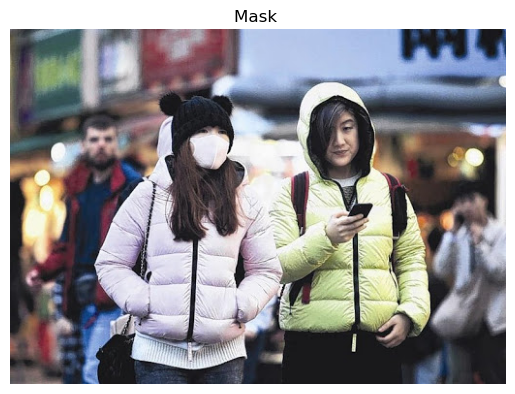

In [156]:
import matplotlib.pyplot as plt

img_path = os.path.join(image_folder, os.listdir(image_folder)[0])
img = cv2.imread(img_path)

img_resized = cv2.resize(img, (100,100))
img_input = np.reshape(img_resized, (1,100,100,3)) / 255.0

pred = model.predict(img_input)

label = "Mask " if np.argmax(pred)==0 else "No Mask "

# Show image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(label)
plt.axis("off")
plt.show()